<a href="https://colab.research.google.com/github/aryaveermajumdar/fsfm-based-neutral-face-project/blob/Version_3/V3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Clone the repo
!git clone https://github.com/wolo-wolo/FSFM-CVPR25.git
%cd /content/FSFM-CVPR25

# Install requirements (skip torch/torchvision — Colab already has a compatible version)
!pip install timm einops huggingface_hub --quiet

Cloning into 'FSFM-CVPR25'...
remote: Enumerating objects: 330, done.
remote: Counting objects: 100% (38/38), done.
remote: Compressing objects: 100% (32/32), done.
remote: Total 330 (delta 25), reused 6 (delta 6), pack-reused 292 (from 1)
Receiving objects: 100% (330/330), 51.37 MiB | 33.98 MiB/s, done.
Resolving deltas: 100% (178/178), done.
/content/FSFM-CVPR25


In [ ]:
# import torch
# import timm

# print("PyTorch:", torch.__version__)
# print("CUDA available:", torch.cuda.is_available())
# print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")
# # Expected: True + T4 on free Colab

In [ ]:
# from huggingface_hub import hf_hub_download
# import os

# os.makedirs('/content/fsfm_checkpoints', exist_ok=True)

# # Download ViT-B/16 pretrained on VGGFace2 for 400 epochs (the main CVPR25 model)
# ckpt_path = hf_hub_download(
#     repo_id="Wolowolo/fsfm-3c",
#     filename="pretrained_models/VF2_ViT-B/checkpoint-400.pth",
#     local_dir="/content/fsfm_checkpoints/",
#     local_dir_use_symlinks=False,
#     resume_download=True
# )

# # Download normalization stats (NOT ImageNet — this is VGGFace2-specific)
# norm_path = hf_hub_download(
#     repo_id="Wolowolo/fsfm-3c",
#     filename="pretrained_models/VF2_ViT-B/pretrain_ds_mean_std.txt",
#     local_dir="/content/fsfm_checkpoints/",
#     local_dir_use_symlinks=False,
#     resume_download=True
# )

# print("Checkpoint downloaded to:", ckpt_path)
# print("Norm stats downloaded to:", norm_path)

In [ ]:
# # Read the actual mean/std FSFM was pretrained with
# with open('/content/fsfm_checkpoints/pretrained_models/VF2_ViT-B/pretrain_ds_mean_std.txt', 'r') as f:
#     lines = f.readlines()
#     print("Norm file contents:", lines)

# # Parse them — file format is typically:
# # mean: [r, g, b]
# # std:  [r, g, b]
# # We'll use these for our transforms later instead of ImageNet defaults

In [ ]:
# import os

# for root, dirs, files in os.walk('/content/FSFM-CVPR25'):
#     for f in files:
#         if 'models_vit' in f:
#             print(os.path.join(root, f))

In [ ]:
# import sys
# import torch

# sys.path.insert(0, '/content/FSFM-CVPR25/fsfm-3c/finuetune/cross_domain_FAS')
# import models_vit

# backbone = models_vit.vit_base_patch16(
#     num_classes=0,
#     drop_path_rate=0.0,
#     global_pool=False
# )

# checkpoint = torch.load(
#     '/content/fsfm_checkpoints/pretrained_models/VF2_ViT-B/checkpoint-400.pth',
#     map_location='cpu',
#     weights_only=False
# )

# state_dict = checkpoint['model']
# msg = backbone.load_state_dict(state_dict, strict=False)
# print("Loaded with message:", msg)

# backbone = backbone.cuda()
# backbone.eval()
# print("Backbone ready. Output dim: 768")

In [ ]:
# import torch

# dummy_images = torch.randn(4, 3, 224, 224).cuda()

# with torch.no_grad():
#     # Call forward_features directly, then extract CLS token (index 0)
#     all_tokens = backbone.forward_features(dummy_images)  # (4, 197, 768)
#     features = all_tokens[:, 0, :]                        # (4, 768) — CLS token only

# print("All tokens shape:", all_tokens.shape)   # (4, 197, 768) — 196 patches + 1 CLS
# print("CLS token shape:", features.shape)      # (4, 768) ← this is what we use
# print("Mean:", features.mean().item())
# print("Std:", features.std().item())

In [3]:
!pip install kagglehub --quiet
import kagglehub

path = kagglehub.dataset_download("fatihkgg/affectnet-yolo-format")
print("Dataset path:", path)

100%|██████████| 258M/258M [00:02<00:00, 94.4MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/fatihkgg/affectnet-yolo-format/versions/2


In [ ]:
# import os

# # Verify the folder structure
# for split in ['train', 'valid', 'test']:
#     img_dir = os.path.join(path, 'YOLO_format', split, 'images')
#     lbl_dir = os.path.join(path, 'YOLO_format', split, 'labels')
#     n_imgs = len(os.listdir(img_dir)) if os.path.exists(img_dir) else 0
#     n_lbls = len(os.listdir(lbl_dir)) if os.path.exists(lbl_dir) else 0
#     print(f"{split}: {n_imgs} images, {n_lbls} labels")

In [ ]:
# import torchvision.transforms as T
# from torch.utils.data import Dataset
# from PIL import Image
# import os
# from collections import Counter

# # Transform (must be defined before dataset)
# MEAN = [0.5482207536697388, 0.42340534925460815, 0.3654651641845703]
# STD  = [0.2789176106452942, 0.2438540756702423,  0.23493893444538116]

# transform = T.Compose([
#     T.Resize((224, 224)),
#     T.ToTensor(),
#     T.Normalize(mean=MEAN, std=STD)
# ])

# CLASSES = ["Anger", "Contempt", "Disgust", "Fear", "Happy", "Neutral", "Sad", "Surprise"]

# class AffectNetYOLO(Dataset):
#     def __init__(self, split, base_path, transform=None):
#         self.img_dir = os.path.join(base_path, 'YOLO_format', split, 'images')
#         self.lbl_dir = os.path.join(base_path, 'YOLO_format', split, 'labels')
#         self.transform = transform

#         self.samples = []
#         for fname in os.listdir(self.img_dir):
#             if not fname.endswith('.jpg'):
#                 continue
#             lbl_file = os.path.join(self.lbl_dir, fname.replace('.jpg', '.txt'))
#             if not os.path.exists(lbl_file):
#                 continue
#             with open(lbl_file) as f:
#                 line = f.readline().strip()
#             if not line:
#                 continue
#             class_id = int(line.split()[0])
#             self.samples.append((os.path.join(self.img_dir, fname), class_id))

#     def __len__(self):
#         return len(self.samples)

#     def __getitem__(self, idx):
#         img_path, label = self.samples[idx]
#         image = Image.open(img_path).convert('RGB')
#         if self.transform:
#             image = self.transform(image)
#         return image, label

# train_ds = AffectNetYOLO('train', path, transform=transform)
# val_ds   = AffectNetYOLO('valid', path, transform=transform)
# print(f"Train: {len(train_ds)} samples")
# print(f"Val:   {len(val_ds)} samples")

# labels = [s[1] for s in train_ds.samples]
# dist = Counter(labels)
# for cid, count in sorted(dist.items()):
#     print(f"  {CLASSES[cid]}: {count}")

In [ ]:
# from torch.utils.data import Dataset
# from PIL import Image
# import os

# CLASSES = ["Anger", "Contempt", "Disgust", "Fear", "Happy", "Neutral", "Sad", "Surprise"]

# class AffectNetYOLO(Dataset):
#     def __init__(self, split, base_path, transform=None):
#         self.img_dir = os.path.join(base_path, 'YOLO_format', split, 'images')
#         self.lbl_dir = os.path.join(base_path, 'YOLO_format', split, 'labels')
#         self.transform = transform

#         # Pair images with their label files
#         self.samples = []
#         for fname in os.listdir(self.img_dir):
#             if not fname.endswith('.jpg'):
#                 continue
#             lbl_file = os.path.join(self.lbl_dir, fname.replace('.jpg', '.txt'))
#             if not os.path.exists(lbl_file):
#                 continue
#             with open(lbl_file) as f:
#                 line = f.readline().strip()
#             if not line:
#                 continue
#             class_id = int(line.split()[0])  # first number is all we need
#             self.samples.append((os.path.join(self.img_dir, fname), class_id))

#     def __len__(self):
#         return len(self.samples)

#     def __getitem__(self, idx):
#         img_path, label = self.samples[idx]
#         image = Image.open(img_path).convert('RGB')
#         if self.transform:
#             image = self.transform(image)
#         return image, label

# # Quick check
# train_ds = AffectNetYOLO('train', path, transform=transform)
# val_ds   = AffectNetYOLO('valid', path, transform=transform)
# print(f"Train: {len(train_ds)} samples")
# print(f"Val:   {len(val_ds)} samples")

# # Check class distribution
# from collections import Counter
# labels = [s[1] for s in train_ds.samples]
# dist = Counter(labels)
# for cid, count in sorted(dist.items()):
#     print(f"  {CLASSES[cid]}: {count}")

In [ ]:
# from torch.utils.data import DataLoader
# import torch

# train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=2)
# val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=2)

# imgs, labels = next(iter(train_loader))
# imgs = imgs.cuda()

# with torch.no_grad():
#     features = backbone.forward_features(imgs)[:, 0, :]

# print("Batch images shape:", imgs.shape)
# print("Batch labels shape:", labels.shape)
# print("Batch features shape:", features.shape)
# print("Sample labels:", labels[:8].tolist())

In [ ]:
# import torch.nn as nn
# import torch.optim as optim

# # --- Classification Head ---
# class EmotionHead(nn.Module):
#     def __init__(self, feature_dim=768, num_classes=8, dropout=0.3):
#         super().__init__()
#         self.classifier = nn.Sequential(
#             nn.Linear(feature_dim, 512),
#             nn.LayerNorm(512),
#             nn.GELU(),
#             nn.Dropout(dropout),
#             nn.Linear(512, 256),
#             nn.GELU(),
#             nn.Dropout(dropout),
#             nn.Linear(256, num_classes)
#         )

#     def forward(self, x):
#         return self.classifier(x)

# head = EmotionHead(num_classes=8).cuda()

# # --- Loss and Optimizer ---
# # Use class weights to counter the imbalance we saw
# from collections import Counter
# import torch

# counts = Counter([s[1] for s in train_ds.samples])
# total = sum(counts.values())
# weights = torch.tensor([total / counts[i] for i in range(8)], dtype=torch.float).cuda()
# weights = weights / weights.sum()  # normalize

# criterion = nn.CrossEntropyLoss(weight=weights)
# optimizer = optim.AdamW(head.parameters(), lr=1e-3, weight_decay=0.05)

# print("Head ready:", sum(p.numel() for p in head.parameters()), "parameters")
# print("Class weights:", {CLASSES[i]: f"{weights[i].item():.3f}" for i in range(8)})

In [ ]:
# # --- Training Loop ---
# NUM_EPOCHS = 10

# for epoch in range(NUM_EPOCHS):
#     head.train()
#     total_loss, correct, total = 0, 0, 0

#     for imgs, labels in train_loader:
#         imgs, labels = imgs.cuda(), labels.cuda()

#         with torch.no_grad():
#             features = backbone.forward_features(imgs)[:, 0, :]  # frozen backbone

#         logits = head(features)
#         loss = criterion(logits, labels)

#         optimizer.zero_grad()
#         loss.backward()
#         optimizer.step()

#         total_loss += loss.item()
#         correct += (logits.argmax(dim=1) == labels).sum().item()
#         total += labels.size(0)

#     train_acc = correct / total

#     # --- Validation ---
#     head.eval()
#     val_correct, val_total = 0, 0
#     with torch.no_grad():
#         for imgs, labels in val_loader:
#             imgs, labels = imgs.cuda(), labels.cuda()
#             features = backbone.forward_features(imgs)[:, 0, :]
#             logits = head(features)
#             val_correct += (logits.argmax(dim=1) == labels).sum().item()
#             val_total += labels.size(0)

#     val_acc = val_correct / val_total
#     print(f"Epoch {epoch+1:02d}/{NUM_EPOCHS} | Loss: {total_loss/len(train_loader):.4f} | Train Acc: {train_acc:.3f} | Val Acc: {val_acc:.3f}")

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from collections import Counter

# Load cached features
train_cache = torch.load('/content/drive/MyDrive/Colab Notebooks/RAF-DB/train_features.pt',
                         weights_only=False)
test_cache  = torch.load('/content/drive/MyDrive/Colab Notebooks/RAF-DB/test_features.pt',
                         weights_only=False)

train_loader = DataLoader(
    TensorDataset(train_cache['features'], train_cache['labels'], train_cache['races']),
    batch_size=256, shuffle=True
)
test_loader = DataLoader(
    TensorDataset(test_cache['features'], test_cache['labels'], test_cache['races']),
    batch_size=256, shuffle=False
)

# Rebuild head
head = nn.Sequential(
    nn.Linear(768, 512),
    nn.LayerNorm(512),
    nn.GELU(),
    nn.Dropout(0.3),
    nn.Linear(512, 256),
    nn.GELU(),
    nn.Dropout(0.3),
    nn.Linear(256, 7)
).cuda()

# Class weights
counts  = Counter(train_cache['labels'].tolist())
total_n = sum(counts.values())
weights = torch.tensor([total_n / counts[i] for i in range(7)], dtype=torch.float).cuda()
weights = weights / weights.sum()
criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = optim.AdamW(head.parameters(), lr=1e-3, weight_decay=0.05)

# Retrain
NUM_EPOCHS = 20
for epoch in range(NUM_EPOCHS):
    head.train()
    total_loss, correct, total = 0, 0, 0
    for feats, labels, _ in train_loader:
        feats, labels = feats.cuda(), labels.cuda()
        logits = head(feats)
        loss   = criterion(logits, labels)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        total_loss += loss.item()
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += labels.size(0)

    head.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for feats, labels, _ in test_loader:
            feats, labels = feats.cuda(), labels.cuda()
            logits = head(feats)
            val_correct += (logits.argmax(1) == labels).sum().item()
            val_total   += labels.size(0)

    print(f"Epoch {epoch+1:02d}/{NUM_EPOCHS} | "
          f"Loss: {total_loss/len(train_loader):.4f} | "
          f"Train: {correct/total:.3f} | "
          f"Val: {val_correct/val_total:.3f}")

Epoch 01/20 | Loss: 1.1962 | Train: 0.586 | Val: 0.726
Epoch 02/20 | Loss: 0.7078 | Train: 0.771 | Val: 0.787
Epoch 03/20 | Loss: 0.5347 | Train: 0.817 | Val: 0.791
Epoch 04/20 | Loss: 0.4364 | Train: 0.842 | Val: 0.792
Epoch 05/20 | Loss: 0.3734 | Train: 0.860 | Val: 0.804
Epoch 06/20 | Loss: 0.3325 | Train: 0.870 | Val: 0.804
Epoch 07/20 | Loss: 0.2785 | Train: 0.887 | Val: 0.802
Epoch 08/20 | Loss: 0.2549 | Train: 0.896 | Val: 0.803
Epoch 09/20 | Loss: 0.2075 | Train: 0.917 | Val: 0.815
Epoch 10/20 | Loss: 0.1793 | Train: 0.926 | Val: 0.831
Epoch 11/20 | Loss: 0.1818 | Train: 0.923 | Val: 0.821
Epoch 12/20 | Loss: 0.1625 | Train: 0.933 | Val: 0.813
Epoch 13/20 | Loss: 0.1613 | Train: 0.935 | Val: 0.803
Epoch 14/20 | Loss: 0.1586 | Train: 0.938 | Val: 0.813
Epoch 15/20 | Loss: 0.1378 | Train: 0.941 | Val: 0.823
Epoch 16/20 | Loss: 0.1247 | Train: 0.949 | Val: 0.839
Epoch 17/20 | Loss: 0.1245 | Train: 0.951 | Val: 0.823
Epoch 18/20 | Loss: 0.1154 | Train: 0.951 | Val: 0.831
Epoch 19/2

In [5]:
import numpy as np

RAFDB_CLASSES = ['Surprise', 'Fear', 'Disgust', 'Happiness', 'Sadness', 'Anger', 'Neutral']
RACE_MAP = {0: 'Caucasian', 1: 'African-American', 2: 'Asian'}

head.eval()
all_preds, all_labels, all_races = [], [], []

with torch.no_grad():
    for feats, labels, races in test_loader:
        feats = feats.cuda()
        logits = head(feats)
        preds = logits.argmax(1).cpu()
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.tolist())
        all_races.extend(races.tolist())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_races  = np.array(all_races)

print("Evaluation done.")
print(f"Total test samples: {len(all_preds)}")

Evaluation done.
Total test samples: 3068


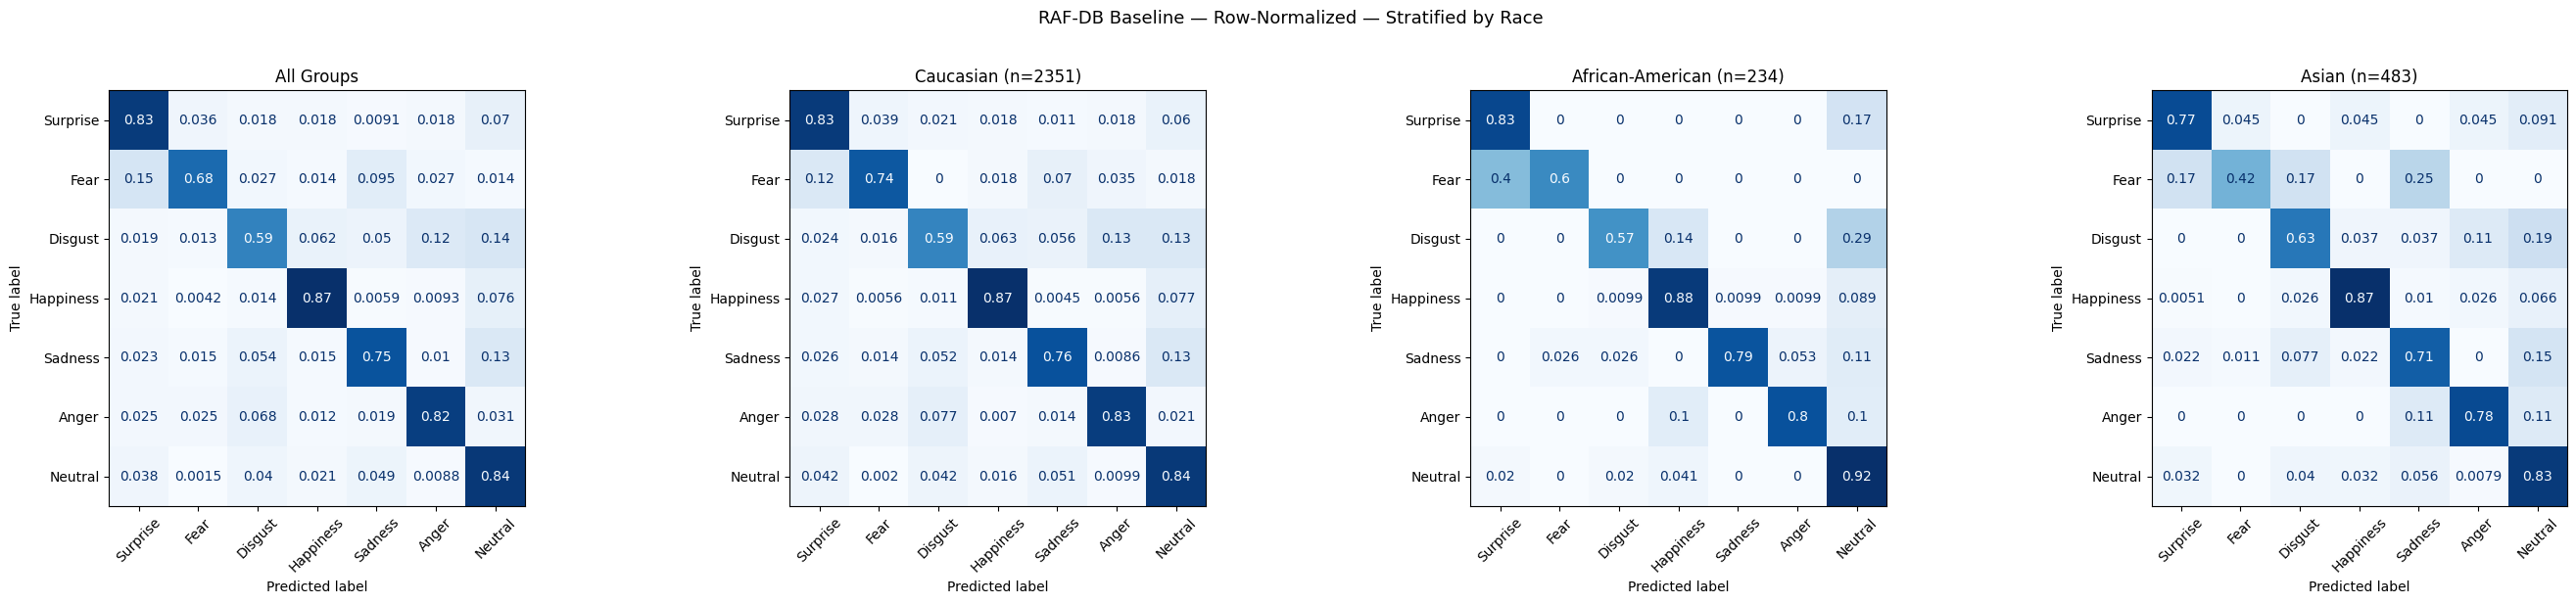

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

RAFDB_CLASSES = ['Surprise', 'Fear', 'Disgust', 'Happiness', 'Sadness', 'Anger', 'Neutral']
RACE_MAP = {0: 'Caucasian', 1: 'African-American', 2: 'Asian'}

fig, axes = plt.subplots(1, 4, figsize=(28, 6))

# Overall
cm_all = confusion_matrix(all_labels, all_preds)
cm_all_norm = cm_all.astype('float') / cm_all.sum(axis=1, keepdims=True)
ConfusionMatrixDisplay(cm_all_norm, display_labels=RAFDB_CLASSES).plot(
    ax=axes[0], cmap='Blues', colorbar=False, xticks_rotation=45)
axes[0].set_title("All Groups")

# Per race
for i, (race_id, race_name) in enumerate(RACE_MAP.items()):
    mask = all_races == race_id
    cm = confusion_matrix(all_labels[mask], all_preds[mask], labels=list(range(7)))
    cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
    ConfusionMatrixDisplay(cm_norm, display_labels=RAFDB_CLASSES).plot(
        ax=axes[i+1], cmap='Blues', colorbar=False, xticks_rotation=45)
    axes[i+1].set_title(f"{race_name} (n={mask.sum()})")

plt.suptitle("RAF-DB Baseline — Row-Normalized — Stratified by Race", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Colab Notebooks/RAF-DB/stratified_cm_normalized.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [7]:
import numpy as np
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize
import torch

RAFDB_CLASSES = ['Surprise', 'Fear', 'Disgust', 'Happiness', 'Sadness', 'Anger', 'Neutral']

head.eval()
all_preds, all_labels, all_races = [], [], []
all_probs = []  # softmax probabilities for AUC

with torch.no_grad():
    for feats, labels, races in test_loader:
        feats = feats.cuda()
        logits = head(feats)
        probs  = torch.softmax(logits, dim=1).cpu()
        preds  = logits.argmax(1).cpu()

        all_probs.extend(probs.tolist())
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.tolist())
        all_races.extend(races.tolist())

all_probs  = np.array(all_probs)   # (N, 7)
all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_races  = np.array(all_races)

# Binarize labels for one-vs-rest AUC
y_bin = label_binarize(all_labels, classes=list(range(7)))

# Per-class recall and AUC
print(f"{'Class':<12} {'Recall':>8} {'AUC':>8}")
print("-" * 30)
for cid, cname in enumerate(RAFDB_CLASSES):
    true_c   = (all_labels == cid)
    pred_c   = (all_preds == cid)
    recall   = (true_c & pred_c).sum() / true_c.sum()
    auc      = roc_auc_score(y_bin[:, cid], all_probs[:, cid])
    print(f"{cname:<12} {recall:>8.3f} {auc:>8.3f}")

# Overall
overall_acc = (all_preds == all_labels).mean()
macro_auc   = roc_auc_score(y_bin, all_probs, multi_class='ovr', average='macro')
print("-" * 30)
print(f"{'Overall':<12} {overall_acc:>8.3f} {macro_auc:>8.3f}")

Class          Recall      AUC
------------------------------
Surprise        0.830    0.977
Fear            0.676    0.967
Disgust         0.594    0.920
Happiness       0.870    0.982
Sadness         0.753    0.975
Anger           0.821    0.980
Neutral         0.843    0.959
------------------------------
Overall         0.820    0.965


In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from collections import Counter
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize
import numpy as np

# --- DemographicConditionedHead ---
class DemographicConditionedHead(nn.Module):
    def __init__(self, feature_dim=768, num_demographics=3,
                 demographic_embed_dim=64, hidden_dim=512,
                 num_emotions=7, dropout=0.3):
        super().__init__()
        self.demographic_embedding = nn.Embedding(num_demographics, demographic_embed_dim)
        combined_dim = feature_dim + demographic_embed_dim
        self.classifier = nn.Sequential(
            nn.Linear(combined_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, num_emotions)
        )

    def forward(self, face_features, demographic_ids):
        demo_emb = self.demographic_embedding(demographic_ids)
        combined = torch.cat([face_features, demo_emb], dim=-1)
        return self.classifier(combined)

# --- Load cached features ---
train_cache = torch.load('/content/drive/MyDrive/Colab Notebooks/RAF-DB/train_features.pt',
                         weights_only=False)
test_cache  = torch.load('/content/drive/MyDrive/Colab Notebooks/RAF-DB/test_features.pt',
                         weights_only=False)

train_loader = DataLoader(
    TensorDataset(train_cache['features'], train_cache['labels'], train_cache['races']),
    batch_size=256, shuffle=True
)
test_loader = DataLoader(
    TensorDataset(test_cache['features'], test_cache['labels'], test_cache['races']),
    batch_size=256, shuffle=False
)

# --- Class weights ---
counts  = Counter(train_cache['labels'].tolist())
total_n = sum(counts.values())
weights = torch.tensor([total_n / counts[i] for i in range(7)], dtype=torch.float).cuda()
weights = weights / weights.sum()
criterion = nn.CrossEntropyLoss(weight=weights)

# --- Train ---
demo_head = DemographicConditionedHead().cuda()
optimizer = optim.AdamW(demo_head.parameters(), lr=1e-3, weight_decay=0.05)

NUM_EPOCHS = 20
for epoch in range(NUM_EPOCHS):
    demo_head.train()
    total_loss, correct, total = 0, 0, 0
    for feats, labels, races in train_loader:
        feats, labels, races = feats.cuda(), labels.cuda(), races.cuda()
        logits = demo_head(feats, races)
        loss   = criterion(logits, labels)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        total_loss += loss.item()
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += labels.size(0)

    demo_head.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for feats, labels, races in test_loader:
            feats, labels, races = feats.cuda(), labels.cuda(), races.cuda()
            logits = demo_head(feats, races)
            val_correct += (logits.argmax(1) == labels).sum().item()
            val_total   += labels.size(0)

    print(f"Epoch {epoch+1:02d}/{NUM_EPOCHS} | "
          f"Loss: {total_loss/len(train_loader):.4f} | "
          f"Train: {correct/total:.3f} | "
          f"Val: {val_correct/val_total:.3f}")

# --- Evaluate with recall + AUC ---
demo_head.eval()
all_preds, all_labels, all_races, all_probs = [], [], [], []

with torch.no_grad():
    for feats, labels, races in test_loader:
        feats = feats.cuda()
        logits = demo_head(feats, races.cuda())
        probs  = torch.softmax(logits, dim=1).cpu()
        all_probs.extend(probs.tolist())
        all_preds.extend(logits.argmax(1).cpu().tolist())
        all_labels.extend(labels.tolist())
        all_races.extend(races.tolist())

all_probs  = np.array(all_probs)
all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_races  = np.array(all_races)

y_bin = label_binarize(all_labels, classes=list(range(7)))

RAFDB_CLASSES = ['Surprise', 'Fear', 'Disgust', 'Happiness', 'Sadness', 'Anger', 'Neutral']
print(f"\n{'Class':<12} {'Recall':>8} {'AUC':>8}")
print("-" * 30)
for cid, cname in enumerate(RAFDB_CLASSES):
    true_c = (all_labels == cid)
    pred_c = (all_preds == cid)
    recall = (true_c & pred_c).sum() / true_c.sum()
    auc    = roc_auc_score(y_bin[:, cid], all_probs[:, cid])
    print(f"{cname:<12} {recall:>8.3f} {auc:>8.3f}")

overall_acc = (all_preds == all_labels).mean()
macro_auc   = roc_auc_score(y_bin, all_probs, multi_class='ovr', average='macro')
print("-" * 30)
print(f"{'Overall':<12} {overall_acc:>8.3f} {macro_auc:>8.3f}")

# --- Neutral recall per race ---
RACE_MAP = {0: 'Caucasian', 1: 'African-American', 2: 'Asian'}
neutral_id = 6
print(f"\nNeutral recall per group:")
for race_id, race_name in RACE_MAP.items():
    mask = all_races == race_id
    true_neutral = (all_labels[mask] == neutral_id)
    pred_neutral = (all_preds[mask] == neutral_id)
    correct = (true_neutral & pred_neutral).sum()
    total   = true_neutral.sum()
    print(f"  {race_name}: {correct}/{total} = {correct/total:.3f}")

Epoch 01/20 | Loss: 1.2246 | Train: 0.576 | Val: 0.699
Epoch 02/20 | Loss: 0.7419 | Train: 0.747 | Val: 0.757
Epoch 03/20 | Loss: 0.5934 | Train: 0.799 | Val: 0.810
Epoch 04/20 | Loss: 0.4818 | Train: 0.821 | Val: 0.784
Epoch 05/20 | Loss: 0.4155 | Train: 0.846 | Val: 0.812
Epoch 06/20 | Loss: 0.3607 | Train: 0.866 | Val: 0.805
Epoch 07/20 | Loss: 0.3060 | Train: 0.879 | Val: 0.810
Epoch 08/20 | Loss: 0.2760 | Train: 0.891 | Val: 0.820
Epoch 09/20 | Loss: 0.2343 | Train: 0.904 | Val: 0.815
Epoch 10/20 | Loss: 0.2025 | Train: 0.915 | Val: 0.810
Epoch 11/20 | Loss: 0.1981 | Train: 0.919 | Val: 0.810
Epoch 12/20 | Loss: 0.1860 | Train: 0.924 | Val: 0.823
Epoch 13/20 | Loss: 0.1922 | Train: 0.919 | Val: 0.825
Epoch 14/20 | Loss: 0.1772 | Train: 0.928 | Val: 0.813
Epoch 15/20 | Loss: 0.1314 | Train: 0.944 | Val: 0.828
Epoch 16/20 | Loss: 0.1303 | Train: 0.949 | Val: 0.823
Epoch 17/20 | Loss: 0.1338 | Train: 0.946 | Val: 0.825
Epoch 18/20 | Loss: 0.1270 | Train: 0.947 | Val: 0.834
Epoch 19/2

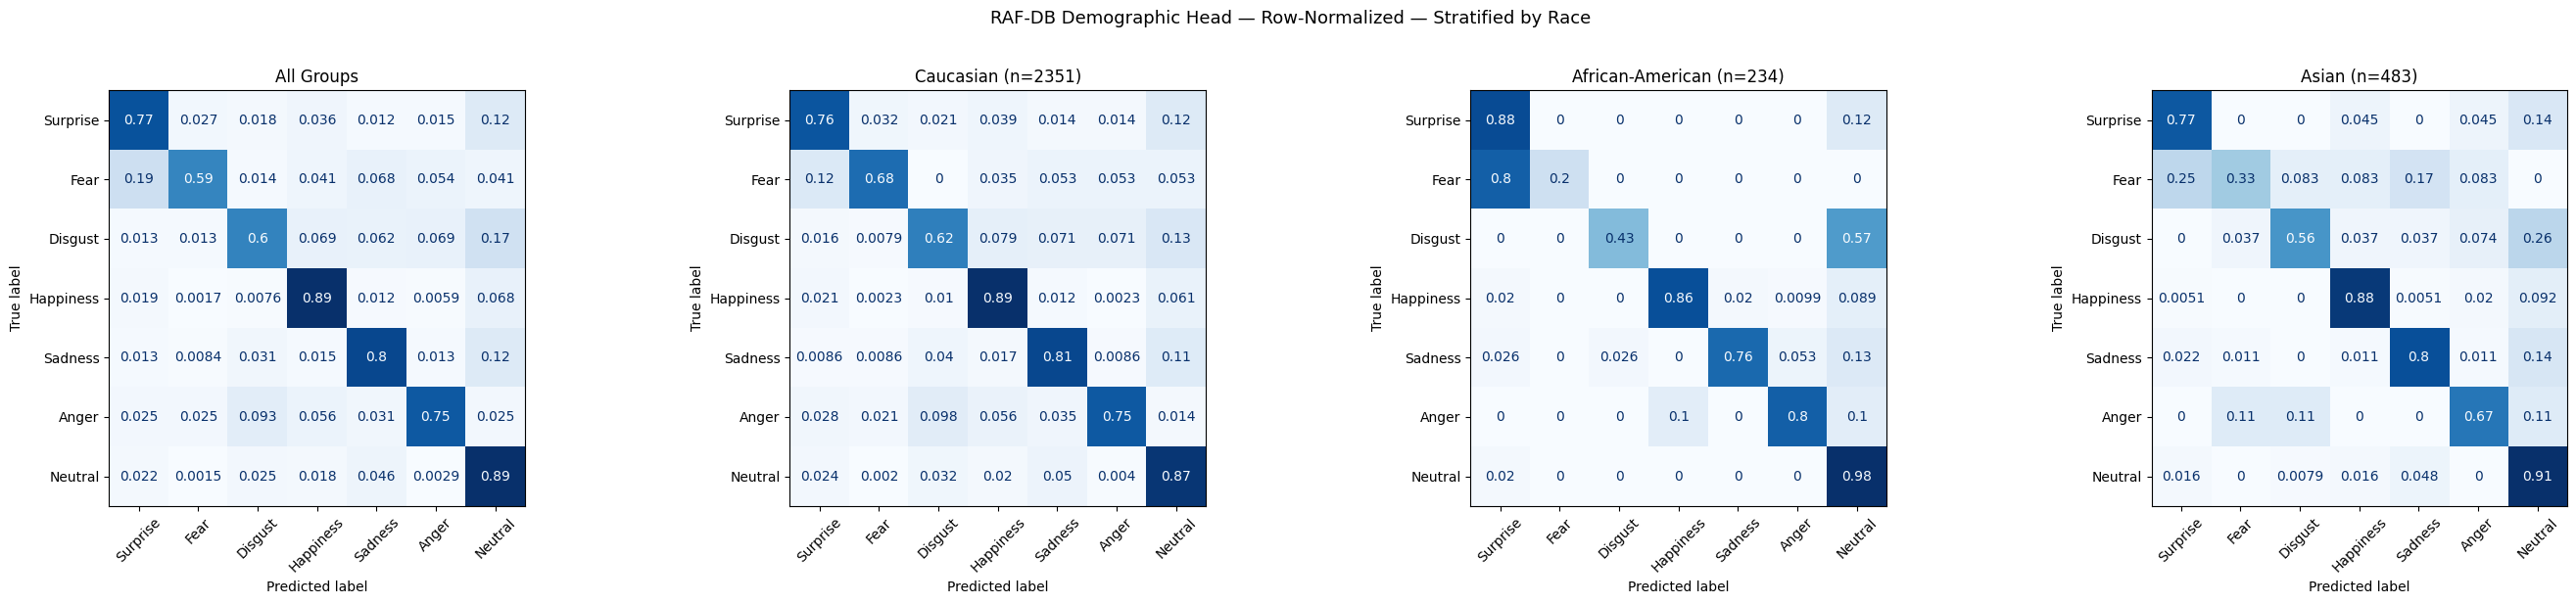

Saved.


In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

RAFDB_CLASSES = ['Surprise', 'Fear', 'Disgust', 'Happiness', 'Sadness', 'Anger', 'Neutral']
RACE_MAP = {0: 'Caucasian', 1: 'African-American', 2: 'Asian'}

fig, axes = plt.subplots(1, 4, figsize=(28, 6))

# Overall
cm_all = confusion_matrix(all_labels, all_preds)
cm_all_norm = cm_all.astype('float') / cm_all.sum(axis=1, keepdims=True)
ConfusionMatrixDisplay(cm_all_norm, display_labels=RAFDB_CLASSES).plot(
    ax=axes[0], cmap='Blues', colorbar=False, xticks_rotation=45)
axes[0].set_title("All Groups")

# Per race
for i, (race_id, race_name) in enumerate(RACE_MAP.items()):
    mask = all_races == race_id
    cm = confusion_matrix(all_labels[mask], all_preds[mask], labels=list(range(7)))
    cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
    ConfusionMatrixDisplay(cm_norm, display_labels=RAFDB_CLASSES).plot(
        ax=axes[i+1], cmap='Blues', colorbar=False, xticks_rotation=45)
    axes[i+1].set_title(f"{race_name} (n={mask.sum()})")

plt.suptitle("RAF-DB Demographic Head — Row-Normalized — Stratified by Race",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Colab Notebooks/RAF-DB/demo_head_cm_normalized.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize
import numpy as np

# --- Linear probe: simplest possible head ---
linear_probe = nn.Linear(768, 7).cuda()
optimizer_lp = optim.AdamW(linear_probe.parameters(), lr=1e-3, weight_decay=0.05)

counts  = Counter(train_cache['labels'].tolist())
total_n = sum(counts.values())
weights = torch.tensor([total_n / counts[i] for i in range(7)], dtype=torch.float).cuda()
weights = weights / weights.sum()
criterion = nn.CrossEntropyLoss(weight=weights)

train_loader = DataLoader(
    TensorDataset(train_cache['features'], train_cache['labels'], train_cache['races']),
    batch_size=256, shuffle=True
)
test_loader = DataLoader(
    TensorDataset(test_cache['features'], test_cache['labels'], test_cache['races']),
    batch_size=256, shuffle=False
)

# --- Train ---
NUM_EPOCHS = 20
for epoch in range(NUM_EPOCHS):
    linear_probe.train()
    correct, total = 0, 0
    for feats, labels, _ in train_loader:
        feats, labels = feats.cuda(), labels.cuda()
        logits = linear_probe(feats)
        loss   = criterion(logits, labels)
        optimizer_lp.zero_grad(); loss.backward(); optimizer_lp.step()
        correct += (logits.argmax(1) == labels).sum().item()
        total   += labels.size(0)

    linear_probe.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for feats, labels, _ in test_loader:
            feats, labels = feats.cuda(), labels.cuda()
            logits = linear_probe(feats)
            val_correct += (logits.argmax(1) == labels).sum().item()
            val_total   += labels.size(0)

    print(f"Epoch {epoch+1:02d}/{NUM_EPOCHS} | "
          f"Train: {correct/total:.3f} | Val: {val_correct/val_total:.3f}")

# --- Evaluate ---
linear_probe.eval()
all_preds_lp, all_labels_lp, all_races_lp, all_probs_lp = [], [], [], []

with torch.no_grad():
    for feats, labels, races in test_loader:
        feats = feats.cuda()
        logits = linear_probe(feats)
        probs  = torch.softmax(logits, dim=1).cpu()
        all_probs_lp.extend(probs.tolist())
        all_preds_lp.extend(logits.argmax(1).cpu().tolist())
        all_labels_lp.extend(labels.tolist())
        all_races_lp.extend(races.tolist())

all_probs_lp  = np.array(all_probs_lp)
all_preds_lp  = np.array(all_preds_lp)
all_labels_lp = np.array(all_labels_lp)
all_races_lp  = np.array(all_races_lp)

y_bin = label_binarize(all_labels_lp, classes=list(range(7)))

RAFDB_CLASSES = ['Surprise', 'Fear', 'Disgust', 'Happiness', 'Sadness', 'Anger', 'Neutral']
RACE_MAP = {0: 'Caucasian', 1: 'African-American', 2: 'Asian'}

print(f"\n{'Class':<12} {'Recall':>8} {'AUC':>8}")
print("-" * 30)
for cid, cname in enumerate(RAFDB_CLASSES):
    true_c = (all_labels_lp == cid)
    pred_c = (all_preds_lp == cid)
    recall = (true_c & pred_c).sum() / true_c.sum()
    auc    = roc_auc_score(y_bin[:, cid], all_probs_lp[:, cid])
    print(f"{cname:<12} {recall:>8.3f} {auc:>8.3f}")

overall_acc = (all_preds_lp == all_labels_lp).mean()
macro_auc   = roc_auc_score(y_bin, all_probs_lp, multi_class='ovr', average='macro')
print("-" * 30)
print(f"{'Overall':<12} {overall_acc:>8.3f} {macro_auc:>8.3f}")

print(f"\nNeutral recall per group:")
neutral_id = 6
for race_id, race_name in RACE_MAP.items():
    mask = all_races_lp == race_id
    true_neutral = (all_labels_lp[mask] == neutral_id)
    pred_neutral = (all_preds_lp[mask] == neutral_id)
    correct = (true_neutral & pred_neutral).sum()
    total   = true_neutral.sum()
    print(f"  {race_name}: {correct}/{total} = {correct/total:.3f}")

Epoch 01/20 | Train: 0.505 | Val: 0.643
Epoch 02/20 | Train: 0.682 | Val: 0.701
Epoch 03/20 | Train: 0.723 | Val: 0.728
Epoch 04/20 | Train: 0.746 | Val: 0.735
Epoch 05/20 | Train: 0.757 | Val: 0.760
Epoch 06/20 | Train: 0.775 | Val: 0.762
Epoch 07/20 | Train: 0.782 | Val: 0.771
Epoch 08/20 | Train: 0.790 | Val: 0.774
Epoch 09/20 | Train: 0.797 | Val: 0.777
Epoch 10/20 | Train: 0.801 | Val: 0.772
Epoch 11/20 | Train: 0.807 | Val: 0.778
Epoch 12/20 | Train: 0.813 | Val: 0.778
Epoch 13/20 | Train: 0.812 | Val: 0.782
Epoch 14/20 | Train: 0.818 | Val: 0.791
Epoch 15/20 | Train: 0.823 | Val: 0.789
Epoch 16/20 | Train: 0.823 | Val: 0.787
Epoch 17/20 | Train: 0.828 | Val: 0.791
Epoch 18/20 | Train: 0.828 | Val: 0.802
Epoch 19/20 | Train: 0.832 | Val: 0.798
Epoch 20/20 | Train: 0.830 | Val: 0.798

Class          Recall      AUC
------------------------------
Surprise        0.815    0.972
Fear            0.703    0.968
Disgust         0.631    0.918
Happiness       0.860    0.979
Sadness      

SyntaxError: invalid syntax (1142123188.py, line 2)